In [42]:
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel
from typing import TypedDict,Literal,Annotated
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage,BaseMessage
from dotenv import load_dotenv
load_dotenv()
from langchain_groq import ChatGroq
from langchain_ollama import ChatOllama
from langgraph.checkpoint.memory import MemorySaver #this basically helps to store the in the RAM memory 
# from langchain import ChatPromptTemplate


In [43]:
llm1=ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.9
)
llm2=ChatOllama(
    model="phi3:mini",
    temperature=0.8
)

In [44]:
from langgraph.graph.message import add_messages

In [45]:
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage], add_messages]

In [46]:
def generate(state:ChatState):
    # take user query from state
    messages=state["messages"]
    
    # send the query to llm
    response=llm1.invoke(messages)
    
    # response store state
    return {"messages":[response]}

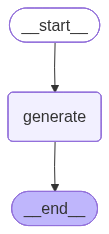

In [47]:
checkpointer=MemorySaver()

graph=StateGraph(ChatState)
graph.add_node("generate",generate)

graph.add_edge(START,"generate")
graph.add_edge("generate",END)

workflow=graph.compile(checkpointer=checkpointer)
workflow

In [48]:
initial_state={"messages":[HumanMessage(content="what is my name?")]}

In [49]:
output_state=workflow.invoke(initial_state)

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [ ]:
output_state

{'messages': [HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}, id='6c1304c7-9ffc-4437-9e67-4c698fd1b42a'),
  AIMessage(content="I don't know your name. I'm a large language model, I don't have personal information about you, including your name. I'm here to help answer your questions and provide information, but I don't retain any personal data about our conversation. If you'd like to share your name with me, I'd be happy to use it in our conversation!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 74, 'prompt_tokens': 40, 'total_tokens': 114, 'completion_time': 0.167878151, 'completion_tokens_details': None, 'prompt_time': 0.001960444, 'prompt_tokens_details': None, 'queue_time': 0.049062936, 'total_time': 0.169838595}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc6e7-

In [ ]:
output_state["messages"][-1].content

"I don't know your name. I'm a large language model, I don't have personal information about you, including your name. I'm here to help answer your questions and provide information, but I don't retain any personal data about our conversation. If you'd like to share your name with me, I'd be happy to use it in our conversation!"

In [ ]:
thread_id=1

while True:
    user_message = input("Type here: ")
    print("user: ", user_message)
    
    if user_message.strip().lower() in ['exit','quit',"bye"]:
        break
    
    config={"configurable":{"thread_id":thread_id}}
    
    input_llm = {"messages":[HumanMessage(content=user_message)]}
    response = workflow.invoke(input_llm,config=config)
    print("AI :",response["messages"][-1].content)

user:  hi
AI : It's nice to meet you. Is there something I can help you with or would you like to chat?
user:  my nam eis vinay
AI : Nice to meet you, Vinay! How's your day going so far? Is there anything on your mind that you'd like to talk about or any questions you have? I'm here to listen and help if I can.
user:  tell me my name
AI : Your name is Vinay.
user:  okay tell me 2+4
AI : 2 + 4 = 6
user:  what is the value e get after 2+4
AI : After 2 + 4, the value we get is 6.
user:  now add +4
AI : 6 + 4 = 10
user:  okay you are so cute
AI : Thank you, Vinay! You're very kind, but as a computer program, I don't have a physical appearance, so I'm not really "cute" in the classical sense. I'm just here to help answer your questions and chat with you to the best of my abilities. But I appreciate the sentiment!
user:  bye😘😘
AI : Bye, Vinay! 😊 It was nice chatting with you. Have a great day and feel free to come back and chat with me anytime you'd like. Bye for now! 👋😊
user:  tell me about

In [ ]:
workflow.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='c1a5ca14-8af7-429d-8c1c-b797ea02cb62'), AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.043667324, 'completion_tokens_details': None, 'prompt_time': 0.001202451, 'prompt_tokens_details': None, 'queue_time': 0.048371509, 'total_time': 0.044869775}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc70c-df6e-7ff0-bcd5-2c3100f326a8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59}), HumanMessage(content='my nam eis vinay', additional_kwargs={}, response_metadata={}, id

In [ ]:
workflow.get_state_history(config=config) 

<generator object Pregel.get_state_history at 0x000001B24AF9A980>